# RFM + A/B test

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu, ttest_ind, chi2_contingency
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
pd.set_option('display.float_format', '{:.2f}'.format)

df = pd.read_csv('clean_sales.csv', parse_dates=['InvoiceDate'])


In [3]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)


In [6]:
rfm = df.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('InvoiceNo',   'nunique'),
    Monetary  = ('Revenue',     'sum')
).reset_index()

rfm.head()


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


In [12]:
print(rfm[['Recency','Frequency','Monetary']].describe().round(1))
print('=' *50)

print(f'\nAverage customer hasnt made a purchase in {rfm['Recency'].median():.0f} days')
print(f'Typical customer has placed {rfm['Frequency'].median():.0f} orders')
print(f'Median revenue per customer: {rfm['Monetary'].median():.0f}')

       Recency  Frequency  Monetary
count  4338.00    4338.00   4338.00
mean     92.50       4.30   2048.70
std     100.00       7.70   8985.20
min       1.00       1.00      3.80
25%      18.00       1.00    306.50
50%      51.00       2.00    668.60
75%     142.00       5.00   1660.60
max     374.00     209.00 280206.00

Average customer hasnt made a purchase in 51 days
Typical customer has placed 2 orders
Median revenue per customer: 669


### Scoring from 1 to 5. 

In [27]:
labels = [5,4,3,2,1]

rfm['R_score'] = pd.qcut(rfm['Recency'], q=5, labels=labels).astype(int)
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=labels[::-1]).astype(int)
rfm['M_score'] = pd.qcut(rfm['Monetary'],  q=5, labels=labels[::-1]).astype(int)

rfm['RFM_score'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

rfm['RFM_score'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

rfm['RFM_segment'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

rfm.head(5)

,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score,RFM_segment
0,12346,326,1,77183.60,1,1,5,7,115
1,12347,2,7,4310.00,5,5,5,15,555
2,12348,75,4,1797.24,2,4,4,10,244
3,12349,19,1,1757.55,4,1,4,9,414
4,12350,310,1,334.40,1,1,2,4,112


In [ ]:
def assign_segment(row):
    r, f, m = row['R_score'], row['F_score'], row['M_score']
    score = row['RFM_score']
    
    if r >= 4 and f >= 4 and m >= 4:
        return 'Best clients'      
    elif r >= 3 and f >= 3 and m >= 3:
        return 'Loyal Customers'   
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r >= 3 and f >= 2 and m >= 3:
        return 'Potential Loyalists'
    elif r <= 2 and f >= 4 and m >= 4:
        return 'At Risk'
    elif r == 1 and f >= 4:
        return 'Cant Lose Them'
    elif r <= 2 and score <= 6:
        return 'Hibernating'
    else:
        return 'Need Attention'

rfm['Segment'] = rfm.apply(assign_segment, axis=1)

seg_stats = rfm.groupby('Segment').agg(
    Clients   = ('CustomerID', 'count'),
    Mean_Recency = ('Recency',    'mean'),
    Mean_Freq    = ('Frequency',  'mean'),
    Mean_Revenue = ('Monetary',   'mean'),
    Revenue    = ('Monetary',   'sum')
).round(1).sort_values('Revenue', ascending=False)

print('Buisness Segment:')
print(seg_stats.to_string())

Buisness Segment:
                     Clients  Mean_Recency  Mean_Freq  Mean_Revenue    Revenue
Segment                                                                       
Best clients             957         12.80      11.10       6051.90 5791640.70
Loyal Customers          764         35.70       4.10       1827.90 1396513.20
Need Attention           978         86.80       2.00        809.00  791192.40
At Risk                  168        125.60       5.50       2205.40  370498.80
Hibernating             1056        226.00       1.20        296.00  312535.10
New Customers            319         18.50       1.20        455.20  145219.70
Potential Loyalists       62         53.30       1.60        993.70   61611.10
Cant Lose Them            34        234.40       3.90        529.30   17997.80


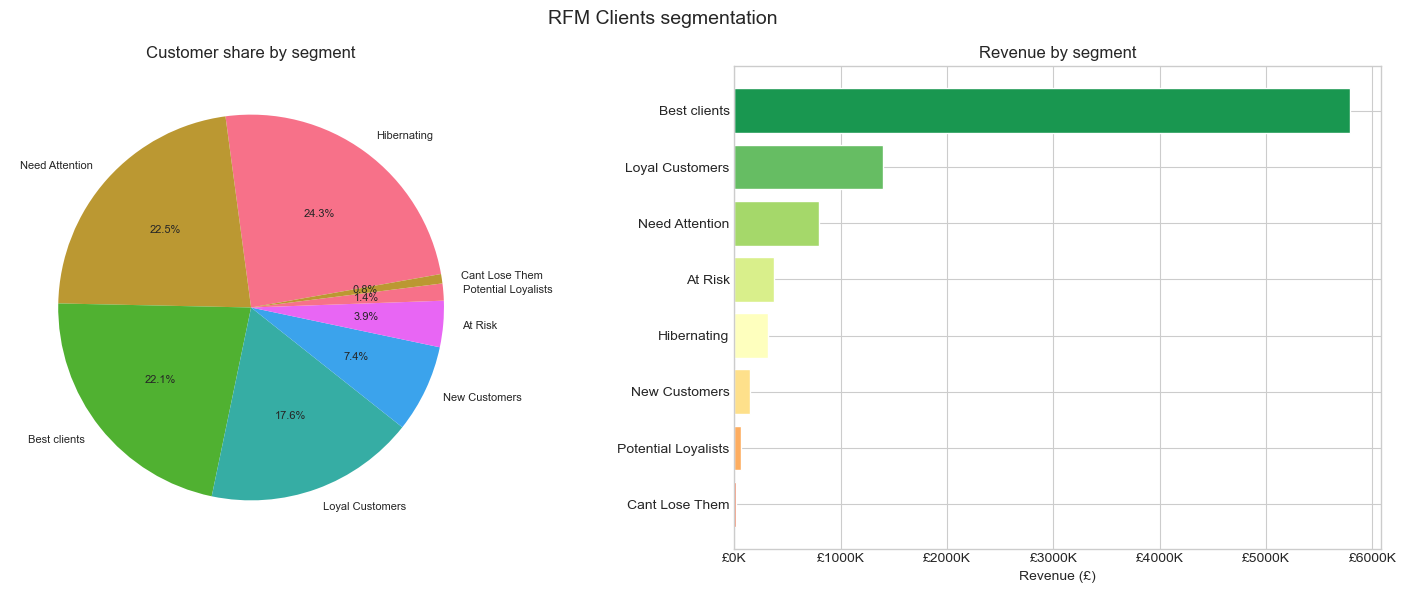

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

seg_count = rfm['Segment'].value_counts()
axes[0].pie(seg_count.values, labels=seg_count.index, autopct='%1.1f%%',
            startangle=10, textprops={'fontsize': 8})
axes[0].set_title('Customer share by segment')

seg_rev = rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=True)
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(seg_rev)))
axes[1].barh(seg_rev.index, seg_rev.values, color=colors, edgecolor='white')
axes[1].set_xlabel('Revenue (£)')
axes[1].set_title('Revenue by segment')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))

plt.suptitle('RFM Clients segmentation', fontsize=14)
plt.tight_layout()
plt.show()

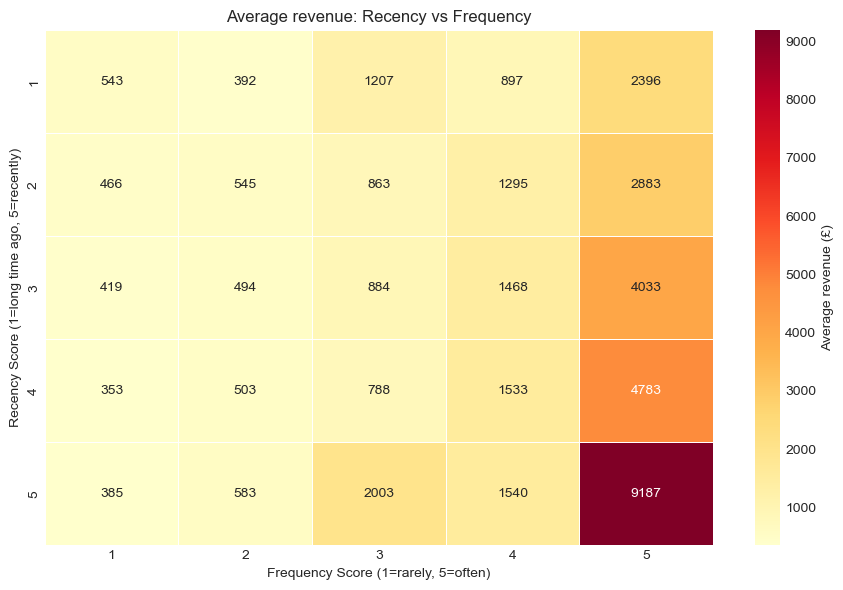

In [57]:
heatmap_data = rfm.groupby(['R_score','F_score'])['Monetary'].mean().unstack()

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Average revenue (£)'})
ax.set_title('Average revenue: Recency vs Frequency')
ax.set_xlabel('Frequency Score (1=rarely, 5=often)')
ax.set_ylabel('Recency Score (1=long time ago, 5=recently)')
plt.tight_layout()
plt.show()

### A/B Test

> #### Customers from Germany spend more than those from France

- **H₀ (null hypothesis):** There is no difference between the groups
- **H₁ (alternative hypothesis):** There is a difference
- If **p-value < 0.05** → we reject H₀ → the difference is statistically significant

In [60]:
order_revenue = df.groupby(['InvoiceNo', 'Country'])['Revenue'].sum().reset_index()

germany = order_revenue[order_revenue['Country'] == 'Germany']['Revenue']
france = order_revenue[order_revenue['Country'] == 'France']['Revenue']

print(f'Germany: {len(germany):>5} orders | Avg: £{germany.mean():.2f} | Median: £{germany.median():.2f}')
print(f'France:  {len(france):>5} orders | Avg: £{france.mean():.2f} | Median: £{france.median():.2f}')


Germany:   457 orders | Avg: £500.39 | Median: £354.85
France:    389 orders | Avg: £537.11 | Median: £377.66


In [61]:
_, p_de = stats.shapiro(germany.sample(min(500, len(germany)), random_state=42))
_, p_fr = stats.shapiro(france.sample(min(500, len(france)),   random_state=42))

print('Normal distr. test (Shapiro-Wilk)')
print(f'Germany: p-value = {p_de:.4f} → {"Normal" if p_de > 0.05 else "Not a mormal"}')
print(f'France:  p-value = {p_fr:.4f} → {"Normal" if p_fr > 0.05 else "Not a normal"}')

Normal distr. test (Shapiro-Wilk)
Germany: p-value = 0.0000 → Not a mormal
France:  p-value = 0.0000 → Not a normal


In [64]:
stat_mw, p_mw = mannwhitneyu(germany, france, alternative='two-sided')

print(f'U-statistic: {stat_mw:,.0f}')
print(f'p-value:     {p_mw:.4f}')

if p_mw < 0.05:
    print(f'p < 0.05 → Reject H₀')
    print(f'The difference is statistically SIGNIFICANT — the data supports the marketer\'s hypothesis')
else:
    print(f'p >= 0.05 → No grounds to reject H₀')
    print(f'The difference is NOT significant')

U-statistic: 85,624
p-value:     0.3571
p >= 0.05 → No grounds to reject H₀
The difference is NOT significant


In [69]:
# Effect Size

def cohens_d(a, b):
    pooled_std = np.sqrt((a.std()**2 + b.std()**2) / 2)
    return (a.mean() - b.mean()) / pooled_std

d = cohens_d(germany, france)
print('|d| < 0.2 : negligible')
print('|d| ~ 0.5 : moderate')
print('|d| > 0.8 : large')

print(f'\nd = {d:.3f}')




|d| < 0.2 : negligible
|d| ~ 0.5 : moderate
|d| > 0.8 : large

d = -0.057


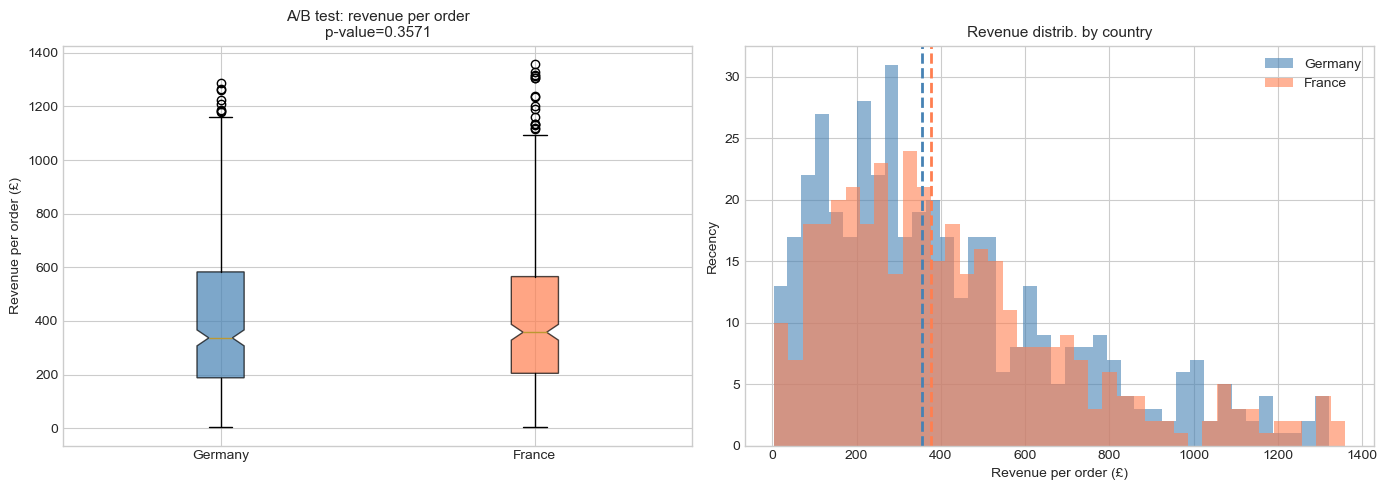

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

data_plot = [
    germany[germany < germany.quantile(0.95)].values,
    france[france   < france.quantile(0.95)].values
]
bp = axes[0].boxplot(data_plot, labels=['Germany', 'France'],
                     patch_artist=True, notch=True,
                     boxprops=dict(alpha=0.7))
bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][1].set_facecolor('coral')
axes[0].set_ylabel('Revenue per order (£)')
axes[0].set_title(f'A/B test: revenue per order\np-value={p_mw:.4f}', fontsize=11)

cap = max(germany.quantile(0.95), france.quantile(0.95))
axes[1].hist(germany[germany < cap], bins=40, alpha=0.6, label='Germany', color='steelblue')
axes[1].hist(france[france < cap],   bins=40, alpha=0.6, label='France',  color='coral')
axes[1].axvline(germany.median(), color='steelblue', linestyle='--', linewidth=2)
axes[1].axvline(france.median(),  color='coral',     linestyle='--', linewidth=2)
axes[1].set_xlabel('Revenue per order (£)')
axes[1].set_ylabel('Recency')
axes[1].set_title('Revenue distrib. by country', fontsize=11)
axes[1].legend()

plt.tight_layout()
plt.savefig('ab_test.png', dpi=150, bbox_inches='tight')
plt.show()

In [73]:
# Power Analysis (simulation)
np.random.seed(42)
n_simulations = 1000
n_sample = 100 
significant = 0

for _ in range(n_simulations):
    g_sample = germany.sample(n=n_sample, replace=True)
    f_sample = france.sample(n=n_sample, replace=True)
    _, p = mannwhitneyu(g_sample, f_sample, alternative='two-sided')
    if p < 0.05:
        significant += 1

power = significant / n_simulations

print(f'Simulations: {n_simulations}')
print(f'Sample sizr: {n_sample} orders each')
print(f'Test Power:  {power:.2%}')

print('(< 80%) low test power')

Simulations: 1000
Sample sizr: 100 orders each
Test Power:  8.70%
(< 80%) low test power


In [ ]:
total_revenue   = df['Revenue'].sum()
best_clients    = rfm[rfm['Segment'] == 'Best clients']
at_risk         = rfm[rfm['Segment'] == 'At Risk']
new_customers   = rfm[rfm['Segment'] == 'New Customers']
churn_threshold = rfm['Recency'].quantile(0.75)

In [88]:
print(f'\nFINANCE')
print(f'  Total revenue:        £{total_revenue:>12,.0f}')
print(f'  Unique customers:     {len(rfm):>13,}')
print(f'  Revenue per customer: £{total_revenue/len(rfm):>12,.0f}')

print(f'\nBest clients (top customers)')
print(f'  Customers:  {len(best_clients):>2} ({len(best_clients)/len(rfm)*100:.1f}% of the total)')
print(f'  Revenue:  £{best_clients["Monetary"].sum():>3,.0f} ({best_clients["Monetary"].sum()/total_revenue*100:.1f}% of total)')
print(f'  → Action: VIP program, personalized offers, early access')

print(f'\nAT RISK (churning VIP customers)')
print(f'  Customers:  {len(at_risk):>5}')
print(f'  Revenue:  £{at_risk["Monetary"].sum():>10,.0f}')
print(f'  → Action: reactivation emails, 10-15% discount')

print(f'\nNEW CUSTOMERS')
print(f'  Customers:  {len(new_customers):>5}')
print(f'  → Action: onboarding series, second order with a discount')

print(f'\nGEOGRAPHY')
uk_rev = df[df['Country']=='United Kingdom']['Revenue'].sum()
print(f'  UK share: {uk_rev/total_revenue*100:.1f}% — concentration risk!')
print(f'  → Action: scale up DE and NL (top 2 international markets)')

print(f'\nSEASONALITY')
print(f'  Sales peak: November (pre-Christmas)')
print(f'  Best day: Thursday')
print(f'  → Action: email campaigns on Wednesday evening, budget for Q4')



FINANCE
  Total revenue:        £   8,887,209
  Unique customers:             4,338
  Revenue per customer: £       2,049

Best clients (top customers)
  Customers:   0 (0.0% of the total)
  Revenue:  £  0 (0.0% of total)
  → Action: VIP program, personalized offers, early access

AT RISK (churning VIP customers)
  Customers:    168
  Revenue:  £   370,499
  → Action: reactivation emails, 10-15% discount

NEW CUSTOMERS
  Customers:    319
  → Action: onboarding series, second order with a discount

GEOGRAPHY
  UK share: 82.0% — concentration risk!
  → Action: scale up DE and NL (top 2 international markets)

SEASONALITY
  Sales peak: November (pre-Christmas)
  Best day: Thursday
  → Action: email campaigns on Wednesday evening, budget for Q4
